<div dir="rtl" align="right">

# سوال 2 و 9
دریافت دیتا 
</div>


In [37]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Load dataset
df = pd.read_csv("../../data/Divar.csv")
df.head()

C:\Users\loki\AppData\Local\Temp\ipykernel_3332\3296383377.py:2: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/Divar.csv")


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

<div dir="rtl" align="right">

# سوال اول
هیستوگرام سال ساخت را رسم کنید.

</div>


In [40]:
# Check construction year column
df["construction_year"].info()

<class 'pandas.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: construction_year
Non-Null Count   Dtype
--------------   -----
815828 non-null  str  
dtypes: str(1)
memory usage: 7.6 MB


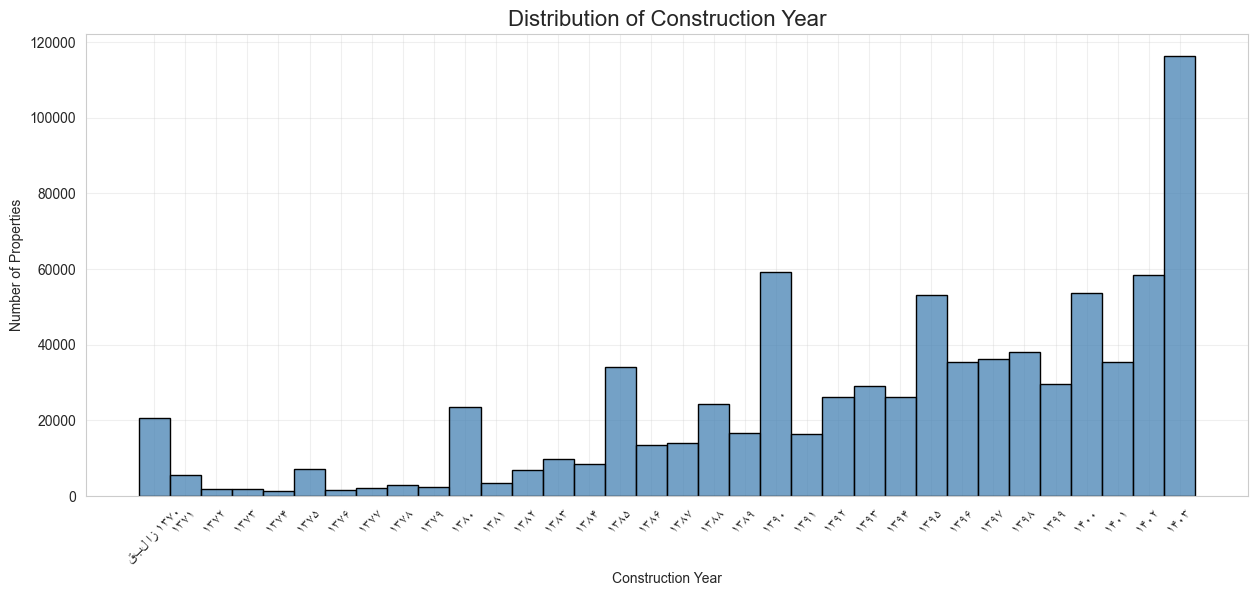

In [41]:
# Plot histogram of construction year
construction_year = df["construction_year"].dropna().sort_values()

plt.figure(figsize=(15,6))

sns.histplot(
    construction_year,
    bins=50,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Construction Year", fontsize=16)
plt.xticks(rotation=45, fontsize=10) 
plt.xlabel("Construction Year")

plt.ylabel("Number of Properties")

plt.grid(alpha=0.3)

plt.show()

<div dir="rtl" align="right">

# مشاهدات سوال اول
به راحتی قابل مشاهده هست که هرچقدر سال ساخت ثدیمی تر باشد اگهی های کمتری به آن سال اختصاص داده شده است و خانه های تازه ساخت اگهی بیشتری دارن و بهتر به فروش یا اجاره میرسند
</div>


<div dir="rtl" align="right">

# سوال دوم
می‌خواهیم بررسی کنیم خانه‌هایی که دارای بالکن، آسانسور، نگهبان، باربیکیو و استخر هستند عمدتا در کدام مناطق قرار دارند. با نمودار مناسب این موضوع را نشان دهید.

</div>


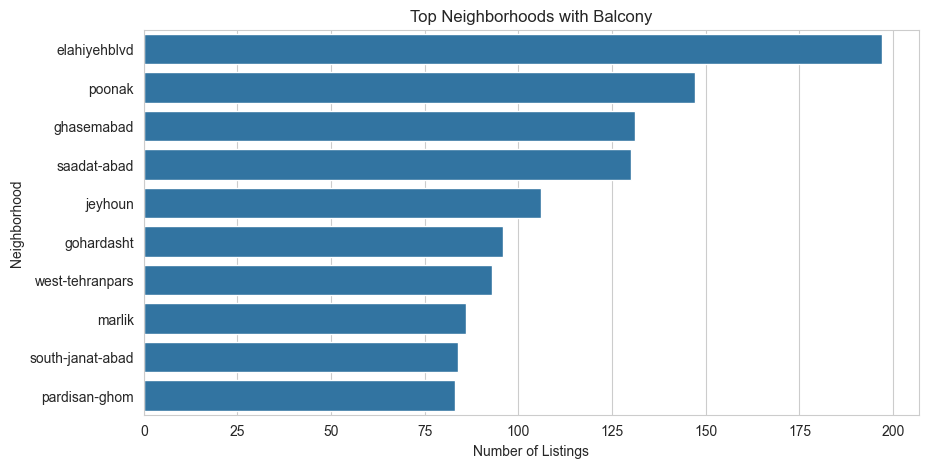

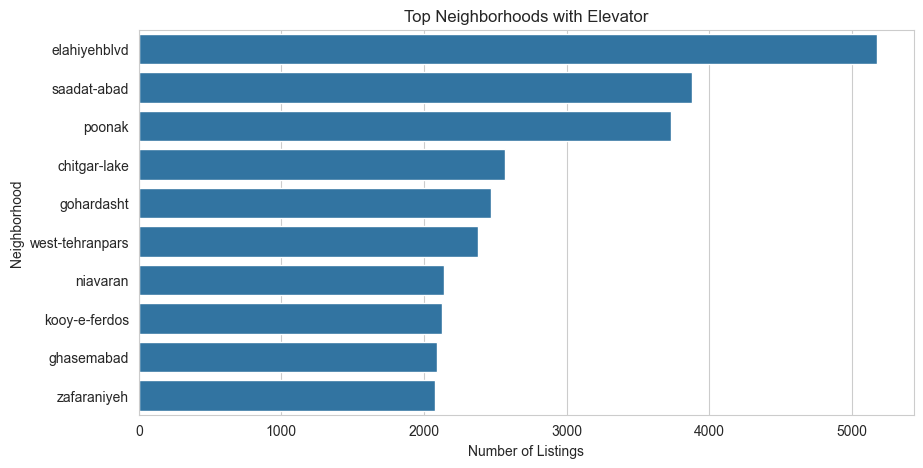

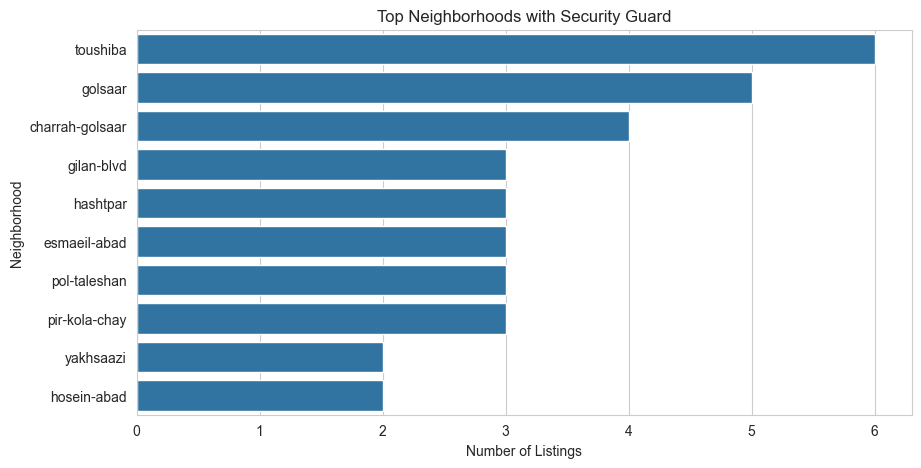

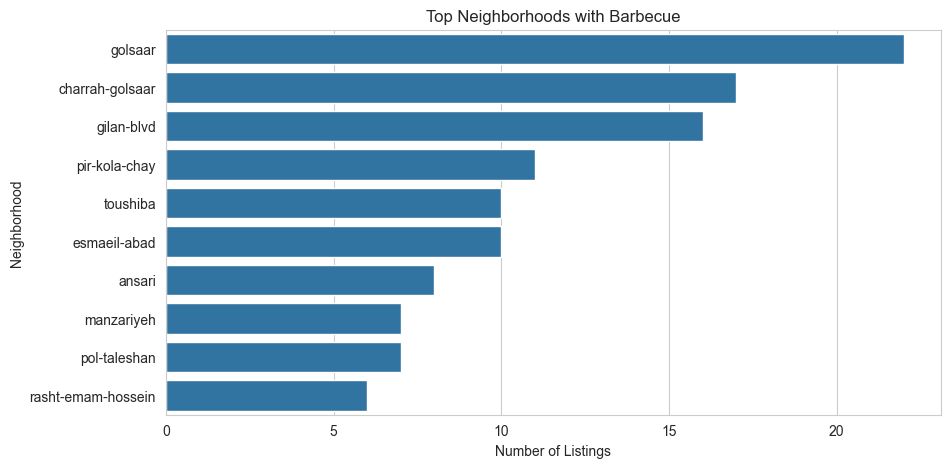

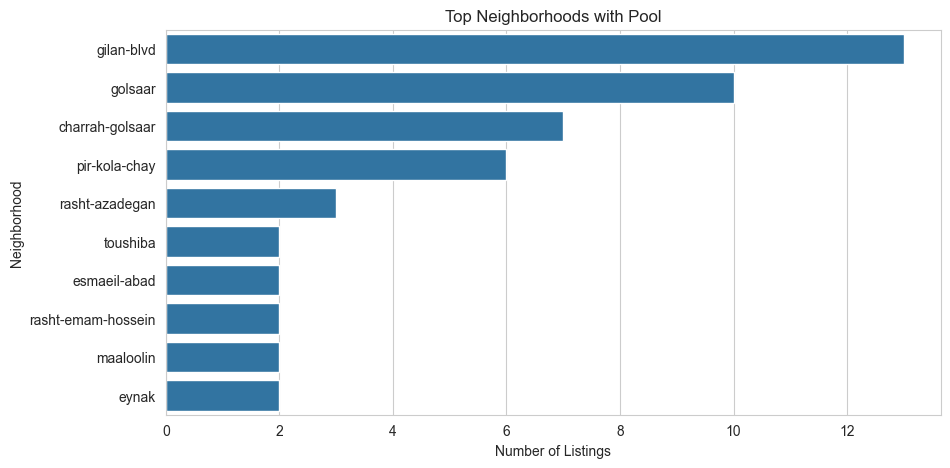

In [42]:
amenities = {
    "has_balcony": "Balcony",
    "has_elevator": "Elevator",
    "has_security_guard": "Security Guard",
    "has_barbecue": "Barbecue",
    "has_pool": "Pool"
}

def plot_top_neighborhoods(feature_column, feature_name):

    top_neighborhoods = (
        df[df[feature_column] == True]
        ["neighborhood_slug"]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=top_neighborhoods.values,
        y=top_neighborhoods.index
    )

    plt.title(f"Top Neighborhoods with {feature_name}")

    plt.xlabel("Number of Listings")

    plt.ylabel("Neighborhood")

    plt.show()


for column, title in amenities.items():

    plot_top_neighborhoods(column, title)

<div dir="rtl" align="right">

# مشاهدات سوال دوم
با توجه به نمودار ها می توان متوجه شد که محله هایی مثل بلوار گیلان، گلسار یا جهاراه گلسار محله های آزاد تری هستند و تراکم خانه های مسکونی کمتر است به دلیل وجود بیشتر استخر و باربیکیو

مقایسه نمودارها نشان می‌دهد امکانات عمومی مانند آسانسور و بالکن در تعداد بیشتری از آگهی‌ها وجود دارند، در حالی که امکاناتی مانند استخر و باربیکیو محدودتر هستند و تعداد کم اگهی ها با استخر و باربیکیو نشان دهنده لوکس بودن و محدود بودن این امکانات در آگهی ها است
</div>
